## PA1: Segmentação de Instâncias com Arquiteturas da Aula
##### Disciplina: Aprendizado Profundo (Deep Learning) — FGV EMAp
##### Professor: Prof. Dario Oliveira | Monitor: Erick Brito
##### Equipe: Jaime Willian Carneiro da Silva e Luiz Eduardo Bravin

### 1. Importações

In [13]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *

import torch
from torch.utils.data import DataLoader, random_split
import numpy as np
import cv2 as cv
from pathlib import Path
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 2. Configurações

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)
PATH_TRAIN = Path('../data/stage1_train')
BATCH_SIZE = 16
IMG_SIZE = 256
print(f'Device: {DEVICE}')

Device: cpu


### 3. Dataset

Escolhemos a opção A - DSB2018 / BBBC038v1 pelo forte interesse que temos em biologia computacional e bioimagem.

Download:  https://bbbc.broadinstitute.org/BBBC038

As classes `DSB2018BinaryDataset` e `DSB2018TernaryDataset` reescrevem as imagens em tensores, respectivamente, para a parte 1 e para a parte 2. As classes `SyntheticBinaryDataset` e `SyntheticTernaryDataset` fazem o mesmo, mas com  imagens de elipsses sintéticas criadas por `generate_synthetic_image`.

### 4. Modelo

Nosso modelo baseia-se na `ResNet34`. As classes que definem `UNetBinary` e `UNetTernary` apresentam encoder, decoder e forward idênticos, exceto pela saída que se adapta a cada parte.

### Parte 1

Primeiramente vamos usar os dados sintéticos:

Train: 536 amostras | Val: 134 amostras
Epoch 1/10 | Loss: 1.1027 | IoU: 0.6410 | Dice: 0.7701
Epoch 2/10 | Loss: 0.5127 | IoU: 0.9395 | Dice: 0.9686
Epoch 3/10 | Loss: 0.2724 | IoU: 0.9486 | Dice: 0.9734
Epoch 4/10 | Loss: 0.1003 | IoU: 0.9673 | Dice: 0.9833
Epoch 5/10 | Loss: 0.0672 | IoU: 0.9741 | Dice: 0.9868
Epoch 6/10 | Loss: 0.0547 | IoU: 0.9753 | Dice: 0.9875
Epoch 7/10 | Loss: 0.0474 | IoU: 0.9822 | Dice: 0.9910
Epoch 8/10 | Loss: 0.0393 | IoU: 0.9825 | Dice: 0.9912
Epoch 9/10 | Loss: 0.0357 | IoU: 0.9882 | Dice: 0.9940
Epoch 10/10 | Loss: 0.0304 | IoU: 0.9881 | Dice: 0.9940
Tempo de treinamento: 1.04 minutos
Melhor IoU (val): 0.9882
Dice corresp.: 0.9940


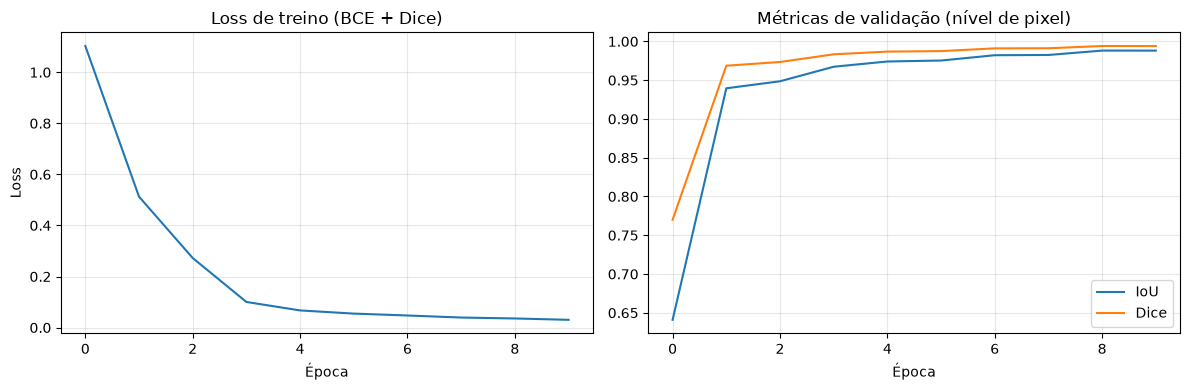

0.50 : 0.0820 | 0.0000
0.55 : 0.0764 | 0.0000
0.60 : 0.0716 | 0.0000
0.65 : 0.0680 | 0.0333
0.70 : 0.0620 | 0.0000
0.75 : 0.0544 | 0.1500
0.80 : 0.0526 | 0.0000
0.85 : 0.0480 | 0.0000
0.90 : 0.0428 | 0.3867
0.95 : 0.0304 | 0.0600
mAP (IoU 0.50:0.95): 0.0588
Média mAP: 0.0842
Média Erro Absoluto: 10.3209


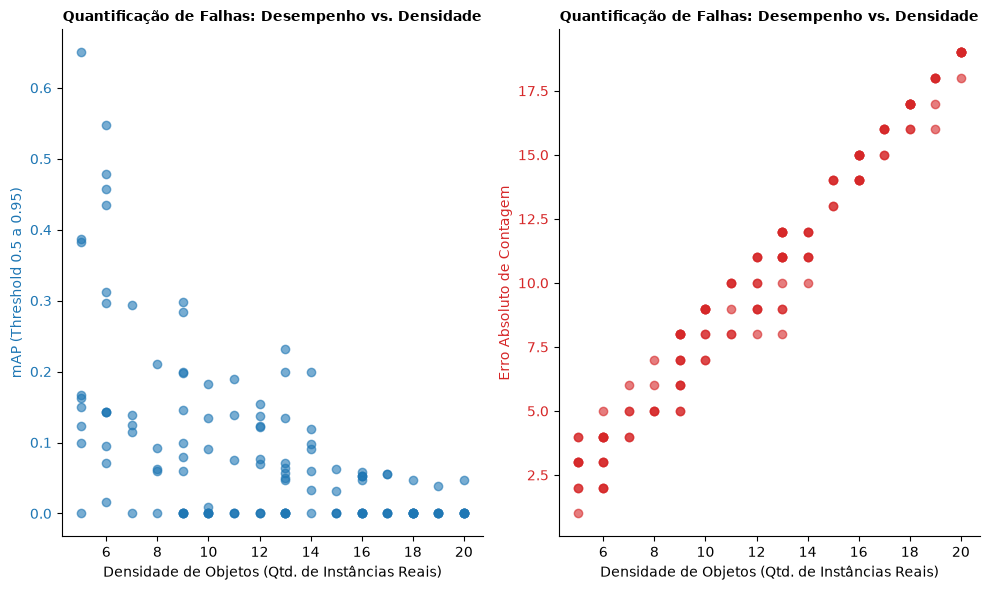

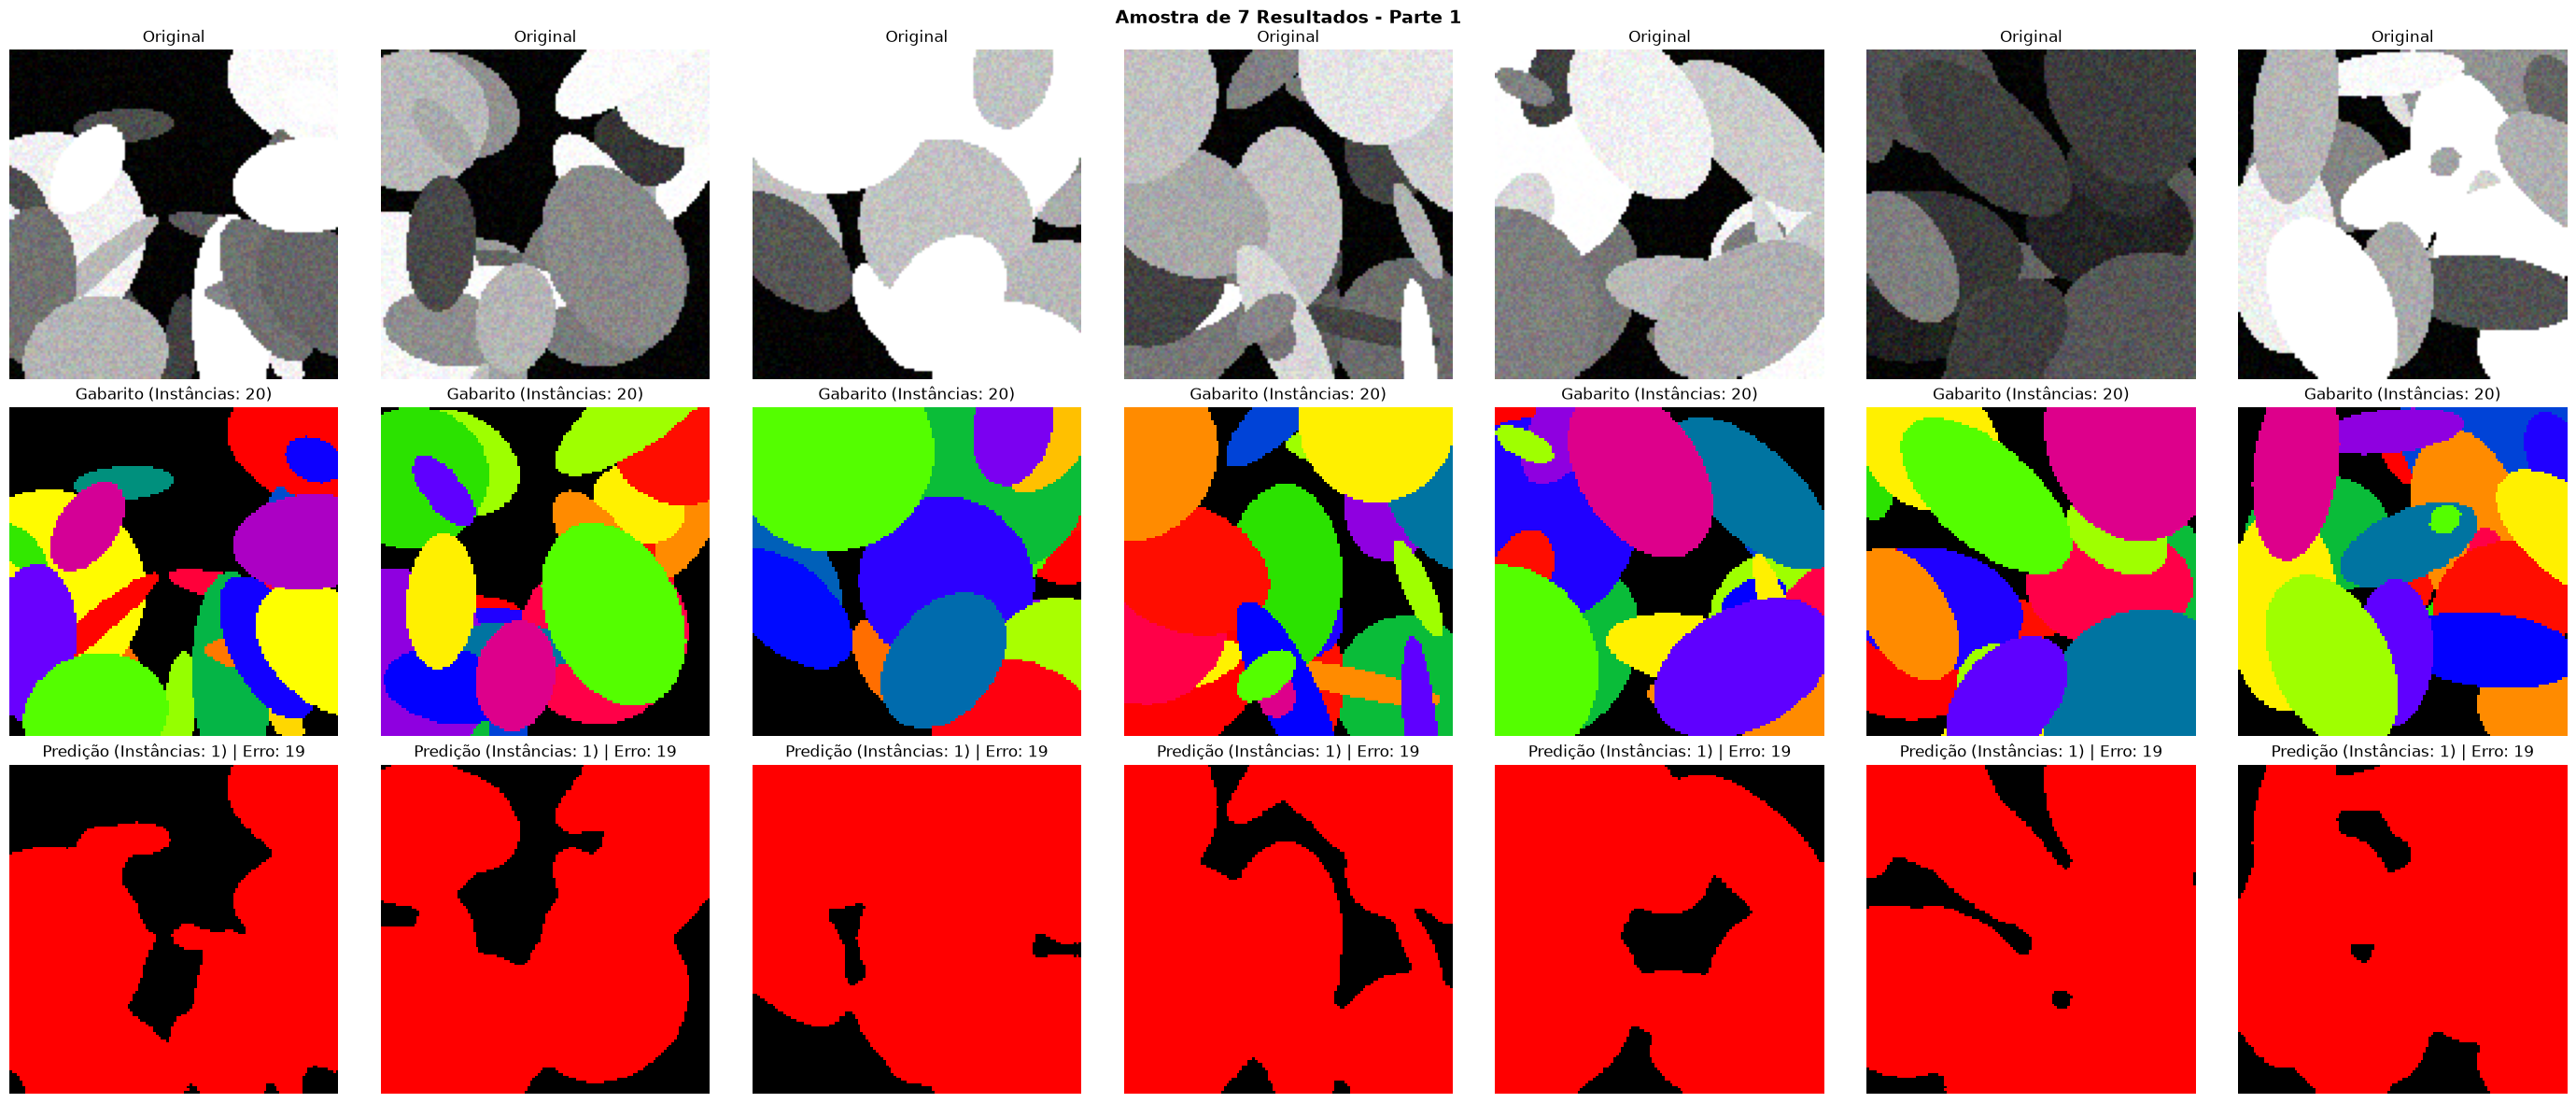

In [ ]:
# Inicialização
model_s1 = UNetBinary().to(DEVICE)
full_ds_s1 = SyntheticBinaryDataset(num_samples=670)
train_ds_s1, val_ds_s2 = random_split(full_ds_s1, split(len(full_ds_s1)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_s1)} amostras | Val: {len(val_ds_s2)} amostras')

train_loader_s1 = DataLoader(train_ds_s1, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_binary, pin_memory=True)
val_loader_s1 = DataLoader(val_ds_s2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_binary, pin_memory=True)


# Treinamento
start_s1 = time.time()
history_s1 = train_model_binary(model_s1, train_loader_s1, val_loader_s1, "s1")
print(f"Tempo de treinamento: {(time.time() - start_s1)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_s1['val_iou']):.4f}")
print(f"Dice corresp.: {history_s1['val_dice'][-1]:.4f}")
plot_training_curves_binary(history_s1)

# Avaliação
model_s1.load_state_dict(torch.load('../models/best_model_s1.pt', map_location=DEVICE, weights_only=True))

aps_s1, count_errors_s1, densities_s1, per_image_aps_s1, samples_s1 = evaluate_instances_binary(model_s1, val_loader_s1)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_s1[i]:.4f} | {per_image_aps_s1[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_s1):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_s1):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_s1):.4f}")

plot_metrics(per_image_aps_s1, count_errors_s1, densities_s1)
plot_samples(samples_s1)

Agora vamos para os dados reais:

In [27]:
# Inicialização
model_binary = UNetBinary().to(DEVICE)
full_ds_binary = DSB2018BinaryDataset(PATH_TRAIN)
train_ds_binary, val_ds_binarytrain_ds_binary = random_split(full_ds_binary, split(len(full_ds_binary)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_binary)} amostras | Val: {len(val_ds_binarytrain_ds_binary)} amostras')

train_loader_binary = DataLoader(train_ds_binary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_binary, pin_memory=True)
val_loader_binary = DataLoader(val_ds_binarytrain_ds_binary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_binary, pin_memory=True)

Train: 536 amostras | Val: 134 amostras


Epoch 1/10 | Loss: 1.4663 | IoU: 0.0000 | Dice: 0.0000
Epoch 2/10 | Loss: 1.0905 | IoU: 0.0001 | Dice: 0.0003
Epoch 3/10 | Loss: 0.8120 | IoU: 0.5062 | Dice: 0.6584
Epoch 4/10 | Loss: 0.5418 | IoU: 0.6140 | Dice: 0.7469
Epoch 5/10 | Loss: 0.4144 | IoU: 0.6597 | Dice: 0.7825
Epoch 6/10 | Loss: 0.3620 | IoU: 0.6907 | Dice: 0.8057
Epoch 7/10 | Loss: 0.3363 | IoU: 0.6967 | Dice: 0.8092
Epoch 8/10 | Loss: 0.3242 | IoU: 0.7280 | Dice: 0.8339
Epoch 9/10 | Loss: 0.3163 | IoU: 0.7330 | Dice: 0.8366
Epoch 10/10 | Loss: 0.2956 | IoU: 0.7282 | Dice: 0.8348
Tempo de treinamento: 1.66 minutos
Melhor IoU (val): 0.7330
Dice corresp.: 0.8348


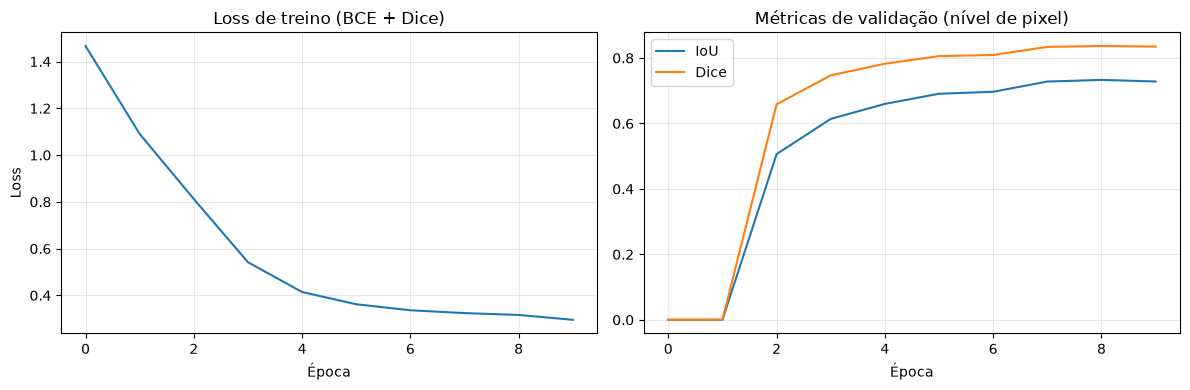

In [28]:
# Treinamento
start_binary = time.time()
history_binary = train_model_binary(model_binary, train_loader_binary, val_loader_binary, "binary")
print(f"Tempo de treinamento: {(time.time() - start_binary)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_binary['val_iou']):.4f}")
print(f"Dice corresp.: {history_binary['val_dice'][-1]:.4f}")
plot_training_curves_binary(history_binary)

IoU : mAP | Média do mAP por imagem
0.50 : 0.3056 | 0.1461
0.55 : 0.2816 | 0.1907
0.60 : 0.2552 | 0.2491
0.65 : 0.2305 | 0.1690
0.70 : 0.1935 | 0.6966
0.75 : 0.1511 | 0.0065
0.80 : 0.1096 | 0.5149
0.85 : 0.0691 | 0.5593
0.90 : 0.0297 | 0.0587
0.95 : 0.0045 | 0.0501
mAP (IoU 0.50:0.95): 0.1631
Média mAP: 0.2852
Média Erro Absoluto: 24.6343


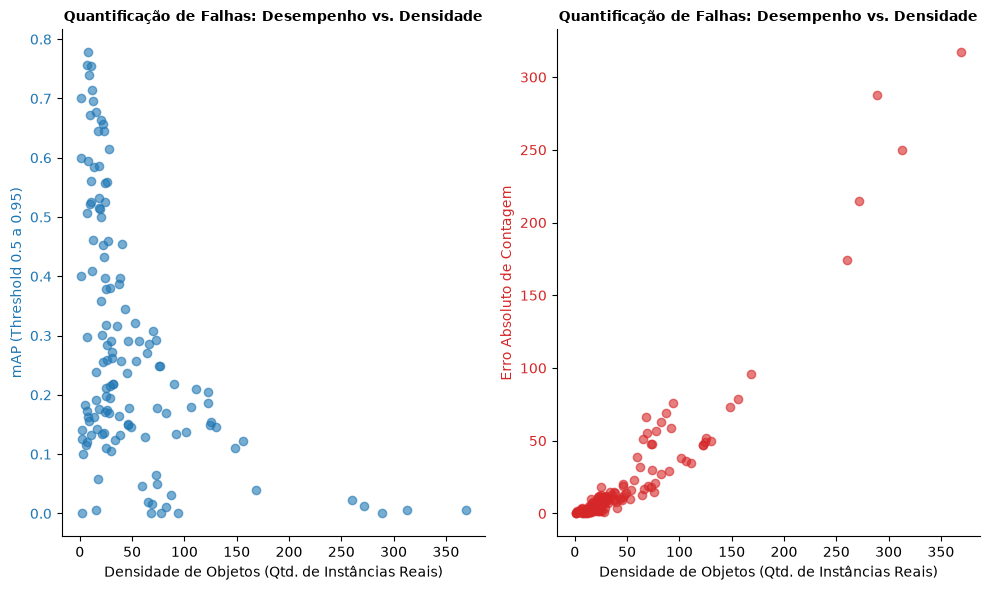

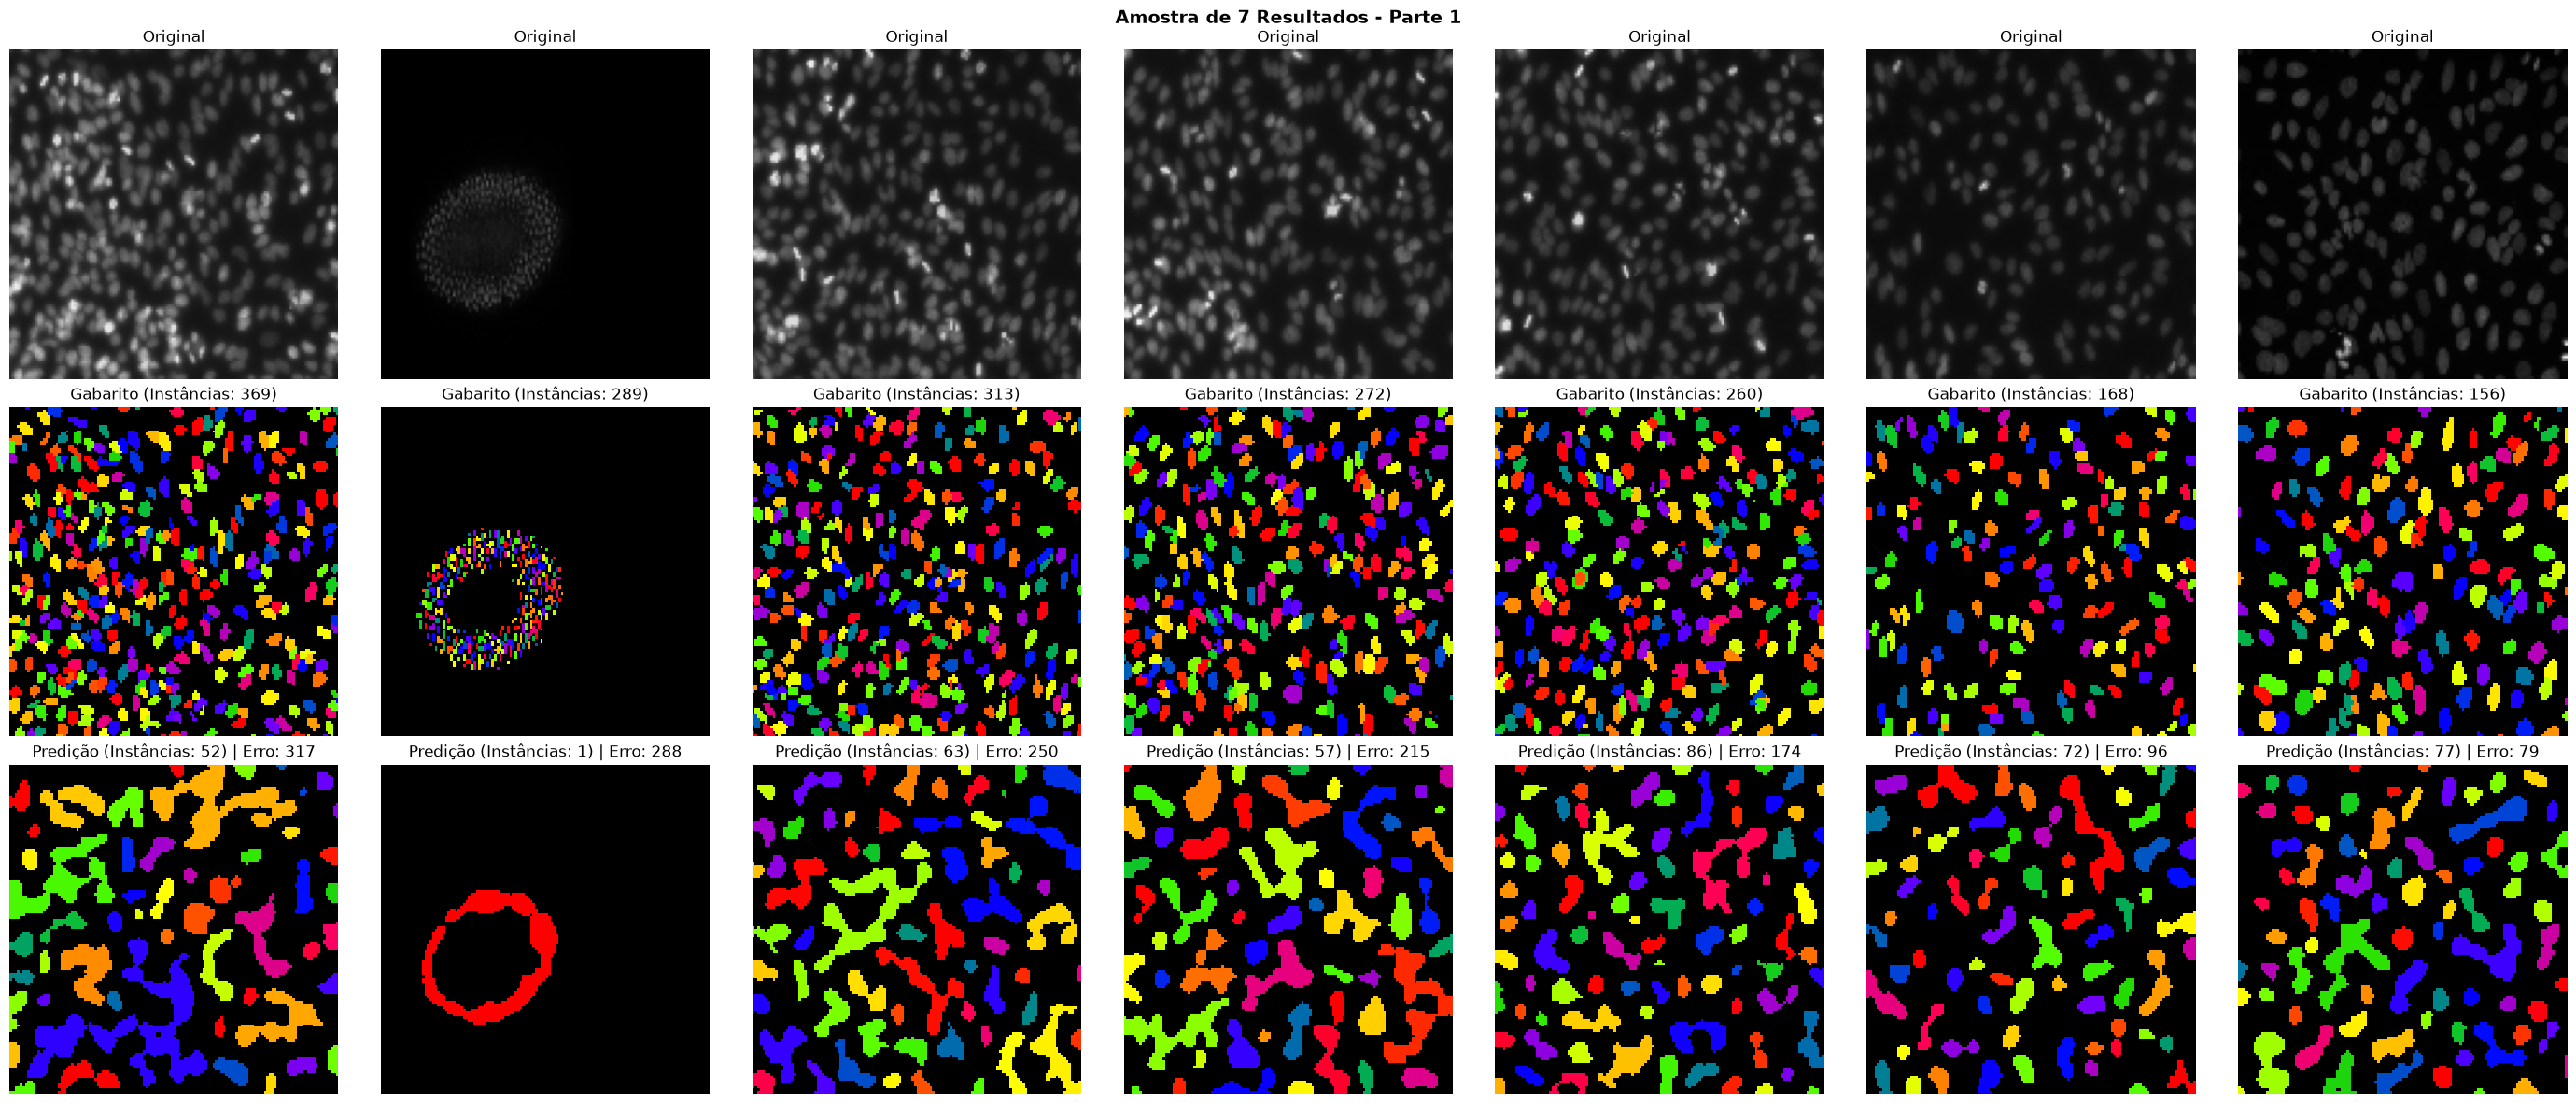

In [29]:
# Avaliação
model_binary.load_state_dict(torch.load('../models/best_model_binary.pt', map_location=DEVICE, weights_only=True))

aps_binary, count_errors_binary, densities_binary, per_image_aps_binary, samples_binary = evaluate_instances_binary(model_binary, val_loader_binary)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_binary[i]:.4f} | {per_image_aps_binary[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_binary):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_binary):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_binary):.4f}")

plot_metrics(per_image_aps_binary, count_errors_binary, densities_binary)
plot_samples(samples_binary)

### Parte 2

Primeiramente vamos usar os dados sintéticos:

Train: 536 amostras | Val: 134 amostras
Epoch 01/10 | Train Loss: 0.8645 | Val Loss: 0.5215 (Cls: 0.3772, Dist: 0.1442)
Epoch 02/10 | Train Loss: 0.5442 | Val Loss: 0.2738 (Cls: 0.1609, Dist: 0.1129)
Epoch 03/10 | Train Loss: 0.5089 | Val Loss: 0.2775 (Cls: 0.1665, Dist: 0.1110)
Epoch 04/10 | Train Loss: 0.4594 | Val Loss: 0.2524 (Cls: 0.1418, Dist: 0.1106)
Epoch 05/10 | Train Loss: 0.4373 | Val Loss: 0.2404 (Cls: 0.1473, Dist: 0.0932)
Epoch 06/10 | Train Loss: 0.5446 | Val Loss: 0.6130 (Cls: 0.4987, Dist: 0.1144)
Epoch 07/10 | Train Loss: 0.4440 | Val Loss: 0.2138 (Cls: 0.1177, Dist: 0.0961)
Epoch 08/10 | Train Loss: 0.4149 | Val Loss: 0.2273 (Cls: 0.1330, Dist: 0.0942)
Epoch 09/10 | Train Loss: 0.3998 | Val Loss: 0.2333 (Cls: 0.1574, Dist: 0.0758)
Epoch 10/10 | Train Loss: 0.3833 | Val Loss: 0.1980 (Cls: 0.1248, Dist: 0.0733)
Tempo de treinamento: 3.20 minutos


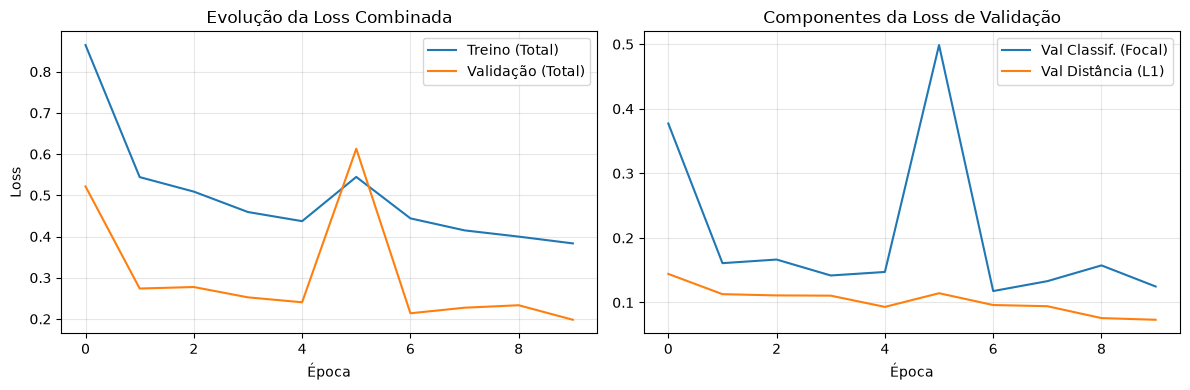

IoU : mAP | Média do mAP por imagem
0.50 : 0.3179 | 0.0883
0.55 : 0.2916 | 0.2688
0.60 : 0.2636 | 0.0862
0.65 : 0.2408 | 0.3594
0.70 : 0.2102 | 0.3190
0.75 : 0.1791 | 0.4455
0.80 : 0.1518 | 0.7700
0.85 : 0.1225 | 0.3313
0.90 : 0.0939 | 0.1637
0.95 : 0.0624 | 0.5128
mAP (IoU 0.50:0.95): 0.1934
Média mAP: 0.2652
Média Erro Absoluto: 2.9627


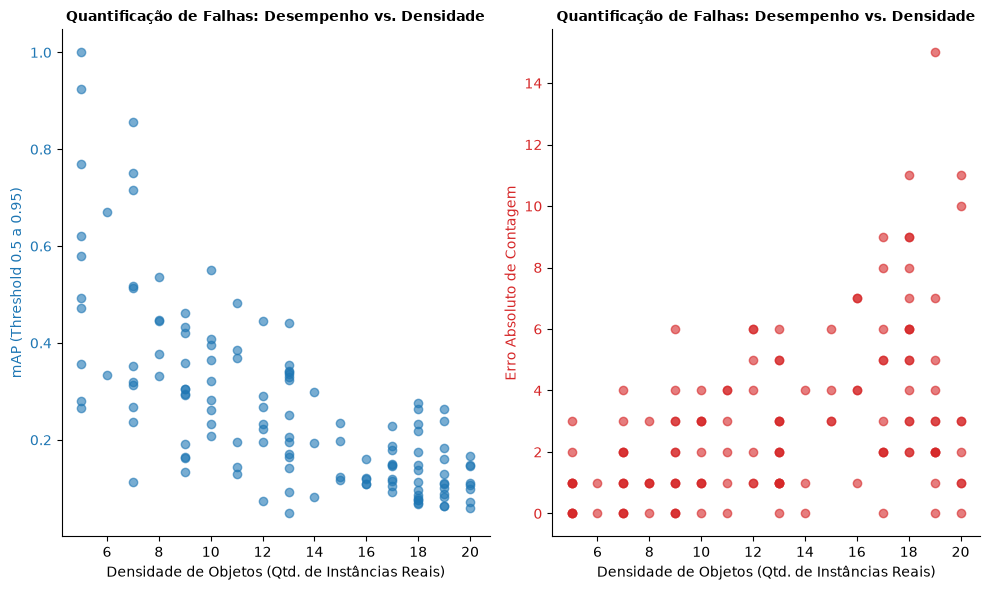

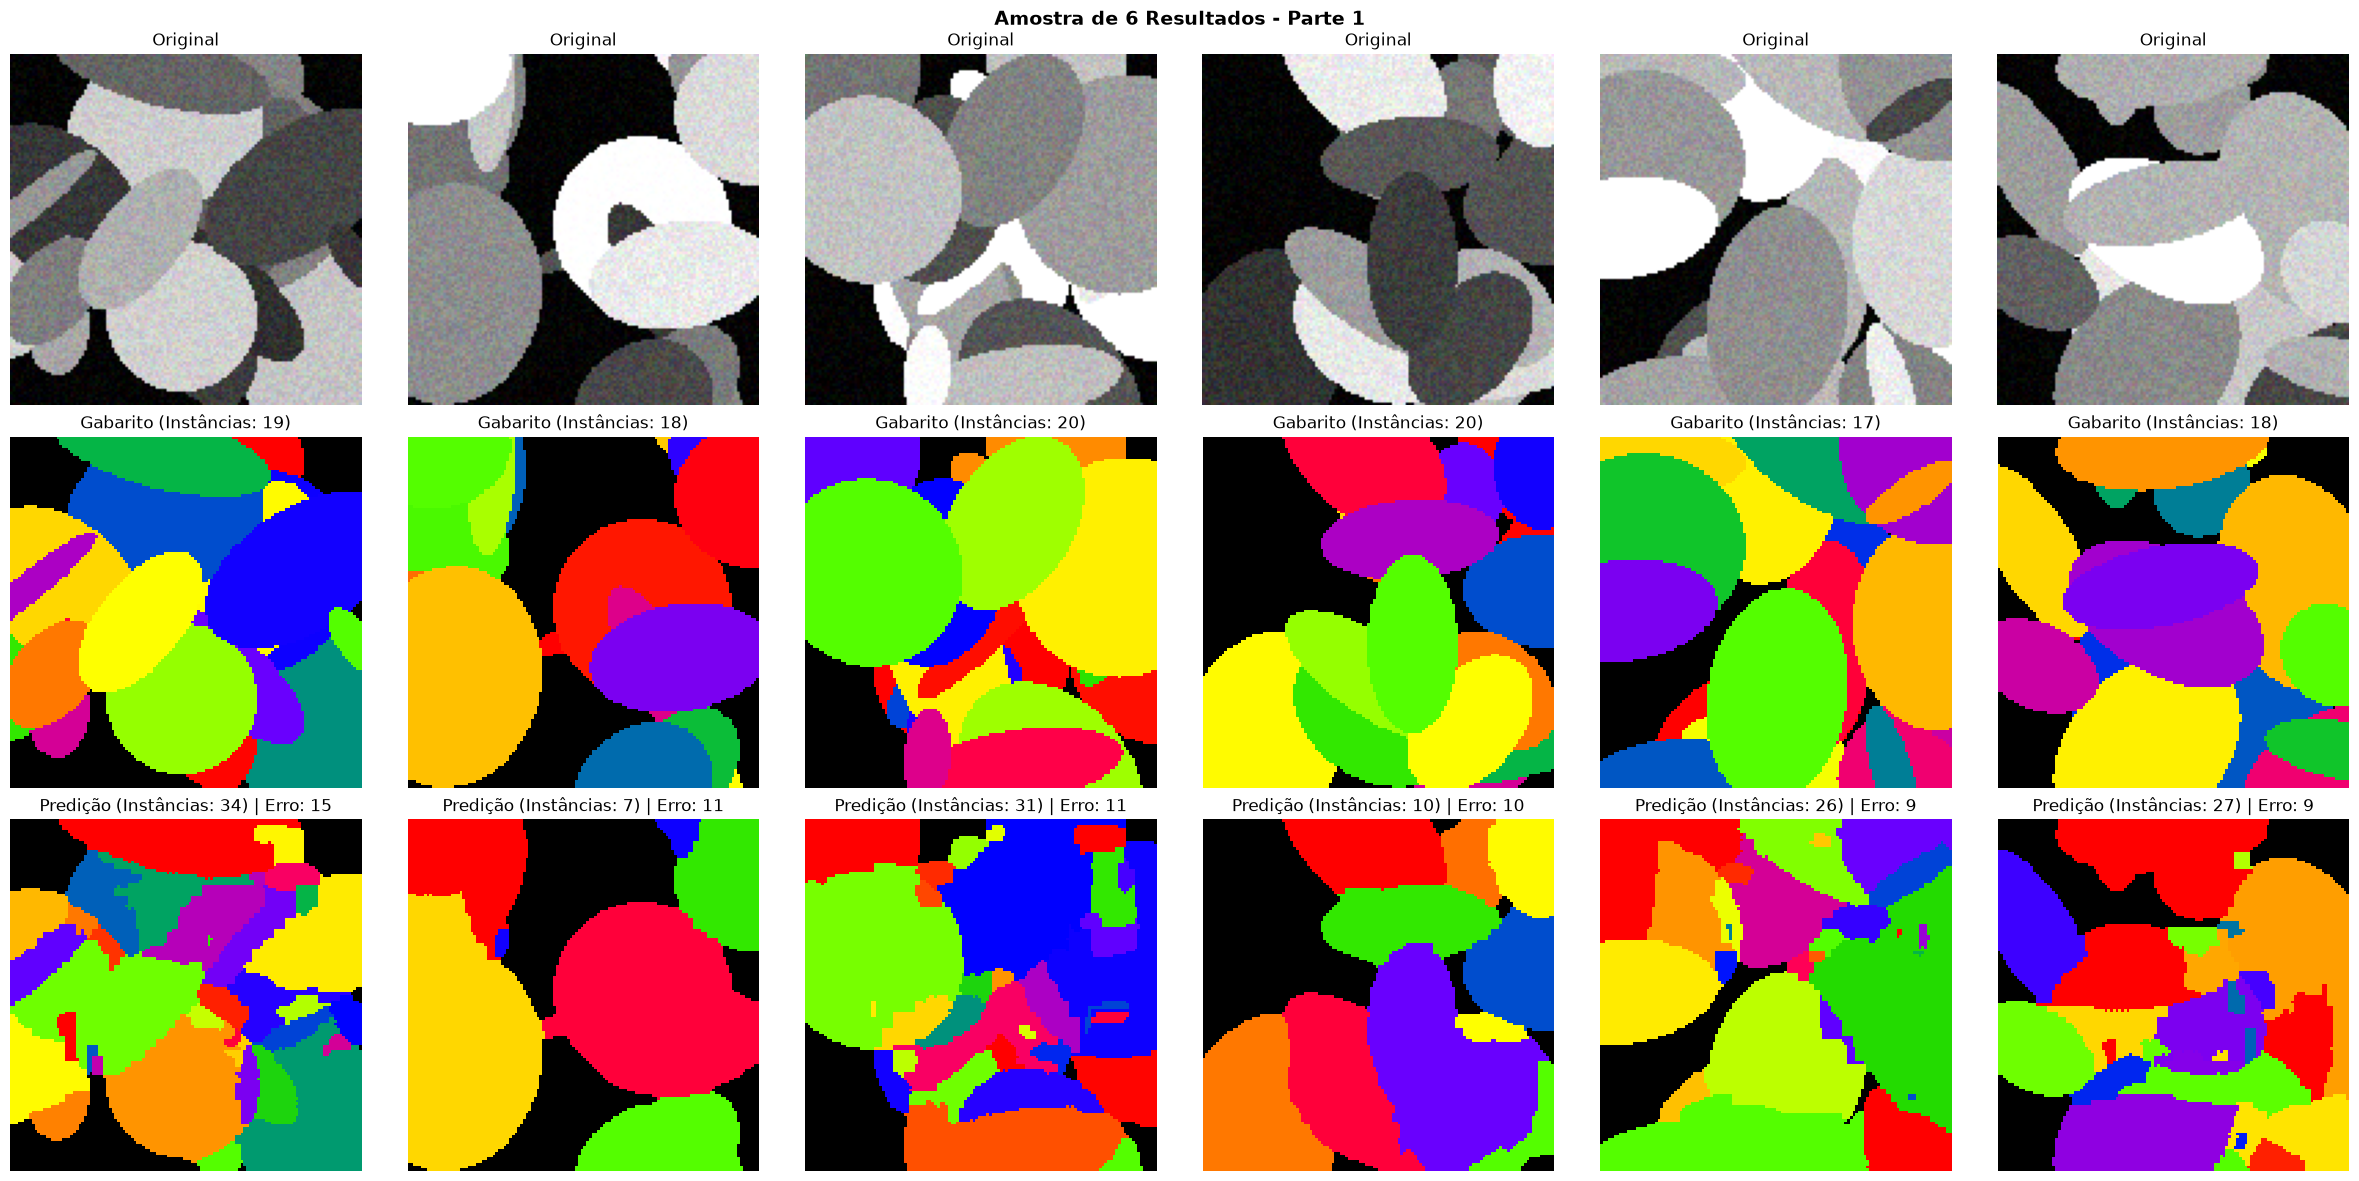

In [ ]:
# Inicialização
model_s2 = UNetTernary().to(DEVICE)
full_ds_s2 = SyntheticTernaryDataset(num_samples=670)
train_ds_s2, val_ds_s2train_ds_s2 = random_split(full_ds_s2, split(len(full_ds_s2)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_s2)} amostras | Val: {len(val_ds_s2train_ds_s2)} amostras')

train_loader_s2 = DataLoader(train_ds_s2, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader_s2 = DataLoader(val_ds_s2train_ds_s2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)

# Treinamento
start_s2 = time.time()
history_s2 = train_model_ternary(model_s2, train_loader_s2, val_loader_s2, "s2")
print(f"Tempo de treinamento: {(time.time() - start_s2)/60:.2f} minutos")
plot_training_curves_ternary(history_s2)

# Avaliação
model_s2.load_state_dict(torch.load('../models/best_model_s2.pt', map_location=DEVICE, weights_only=True))
aps_s2, count_errors_s2, densities_s2, per_image_aps_s2, samples_s2 = evaluate_instances_ternary(model_s2, val_loader_s2)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_s2[i]:.4f} | {per_image_aps_s2[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_s2):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_s2):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_s2):.4f}")

plot_metrics(per_image_aps_s2, count_errors_s2, densities_s2)
plot_samples(samples_s2)

Agora vamos para os dados reais:

In [3]:
# Inicialização
model_ternary = UNetTernary().to(DEVICE)
full_ds_ternary = DSB2018TernaryDataset(PATH_TRAIN, img_size=256)
train_ds_ternary, val_ds_ternary = random_split(full_ds_ternary, split(len(full_ds_ternary)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_ternary)} amostras | Val: {len(val_ds_ternary)} amostras')

train_loader_ternary = DataLoader(train_ds_ternary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader_ternary = DataLoader(val_ds_ternary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)

Train: 536 amostras | Val: 134 amostras


In [16]:
# Treinamento
start_ternary = time.time()
history_ternary = train_model_ternary(model_ternary, train_loader_ternary, val_loader_ternary, "ternary")
print(f"Tempo de treinamento: {(time.time() - start_ternary)/60:.2f} minutos")
plot_training_curves_ternary(history_ternary)


/home/jaimewillian/Documentos/FGV/6P/DL/deep-learning-assignments/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [42]:
@torch.no_grad()
def evaluate_instances_ternary(
		model,
		loader,
		interior_thresh=0.55,
		fg_thresh=0.5,
		min_marker_size=5,
		k_samples=6,
):
	"""Avaliação idêntica à Parte 1: matching guloso por IoU decrescente."""
	model.eval()
	n_threshold = len(IOU_THRESHOLDS)
	tp_total = np.zeros(n_threshold)
	denom_total = np.zeros(n_threshold)

	count_errors = []
	densities = []
	per_image_aps = []
	samples = []

	for images, _, _, instance_masks_batch, _ in loader:
		images = images.to(DEVICE)
		logits_cls, dist_pred = model(images)
		probs_batch = F.softmax(logits_cls, dim=1).cpu().numpy()
		dists_batch = dist_pred.squeeze(1).cpu().numpy()

		for b in range(images.size(0)):
			pred_masks = decode_watershed(
					probs_batch[b],
					dists_batch[b],
					interior_thresh=interior_thresh,
					fg_thresh=fg_thresh,
					min_marker_size=min_marker_size,
			)
			gt_masks = instance_masks_batch[b]
			n_pred, n_gt = len(pred_masks), len(gt_masks)

			count_err = abs(n_pred - n_gt)
			count_errors.append(count_err)
			densities.append(n_gt)

			img_np = images[b].cpu().numpy().transpose(1, 2, 0)
			samples.append((count_err, img_np, gt_masks, pred_masks))

			if n_pred == 0 and n_gt == 0:
				per_image_aps.append(1.0)
				continue
			if n_pred == 0 or n_gt == 0:
				denom_total += n_pred + n_gt
				per_image_aps.append(0.0)
				continue

			# Matriz de IoU Vetorizada
			pred_flat = np.array(pred_masks, dtype=np.int32).reshape(n_pred, -1)
			gt_flat = np.array(gt_masks, dtype=np.int32).reshape(n_gt, -1)
			inter = np.dot(pred_flat, gt_flat.T)
			area_pred = pred_flat.sum(axis=1)[:, np.newaxis]
			area_gt = gt_flat.sum(axis=1)[np.newaxis, :]
			union = area_pred + area_gt - inter
			iou_matrix = inter / np.maximum(union, 1e-6)

			pairs = [
					(iou_matrix[i, j], i, j)
					for i in range(n_pred)
					for j in range(n_gt)
					if iou_matrix[i, j] > 0
			]
			pairs.sort(key=lambda x: -x[0])

			img_aps = np.zeros(n_threshold)
			for k, t in enumerate(IOU_THRESHOLDS):
				matched_pred, matched_gt = set(), set()
				tp = 0
				for iou, i, j in pairs:
					if iou < t:
						break
					if i not in matched_pred and j not in matched_gt:
						matched_pred.add(i)
						matched_gt.add(j)
						tp += 1
				fp = n_pred - tp
				fn = n_gt - tp
				denom = tp + fp + fn
				img_aps[k] = tp / denom if denom > 0 else 1.0

				tp_total[k] += tp
				denom_total[k] += denom

			per_image_aps.append(float(img_aps.mean()))

	aps = np.where(denom_total > 0, tp_total / denom_total, 1.0)
	samples.sort(key=lambda s: -s[0])
	return aps, count_errors, densities, per_image_aps, samples[:k_samples]



IoU : mAP | Média do mAP por imagem
0.50 : 0.5145 | 0.2724
0.55 : 0.4935 | 0.3646
0.60 : 0.4732 | 0.4770
0.65 : 0.4491 | 0.3554
0.70 : 0.4148 | 0.8093
0.75 : 0.3660 | 0.0829
0.80 : 0.2978 | 0.5561
0.85 : 0.2069 | 0.7215
0.90 : 0.1027 | 0.1436
0.95 : 0.0168 | 0.3145
mAP (IoU 0.50:0.95): 0.3335
Média mAP: 0.4525
Média Erro Absoluto: 17.8731


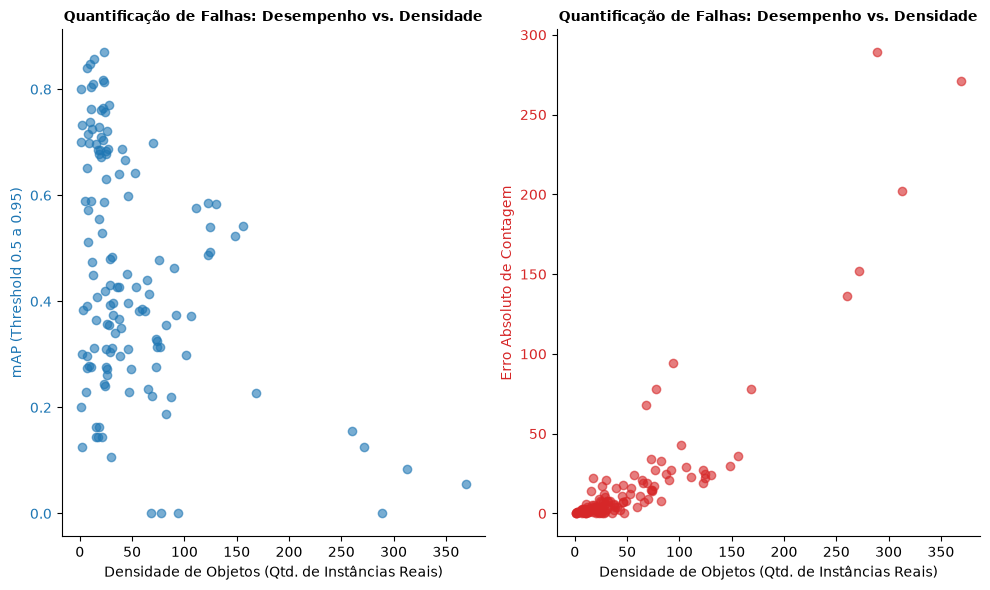

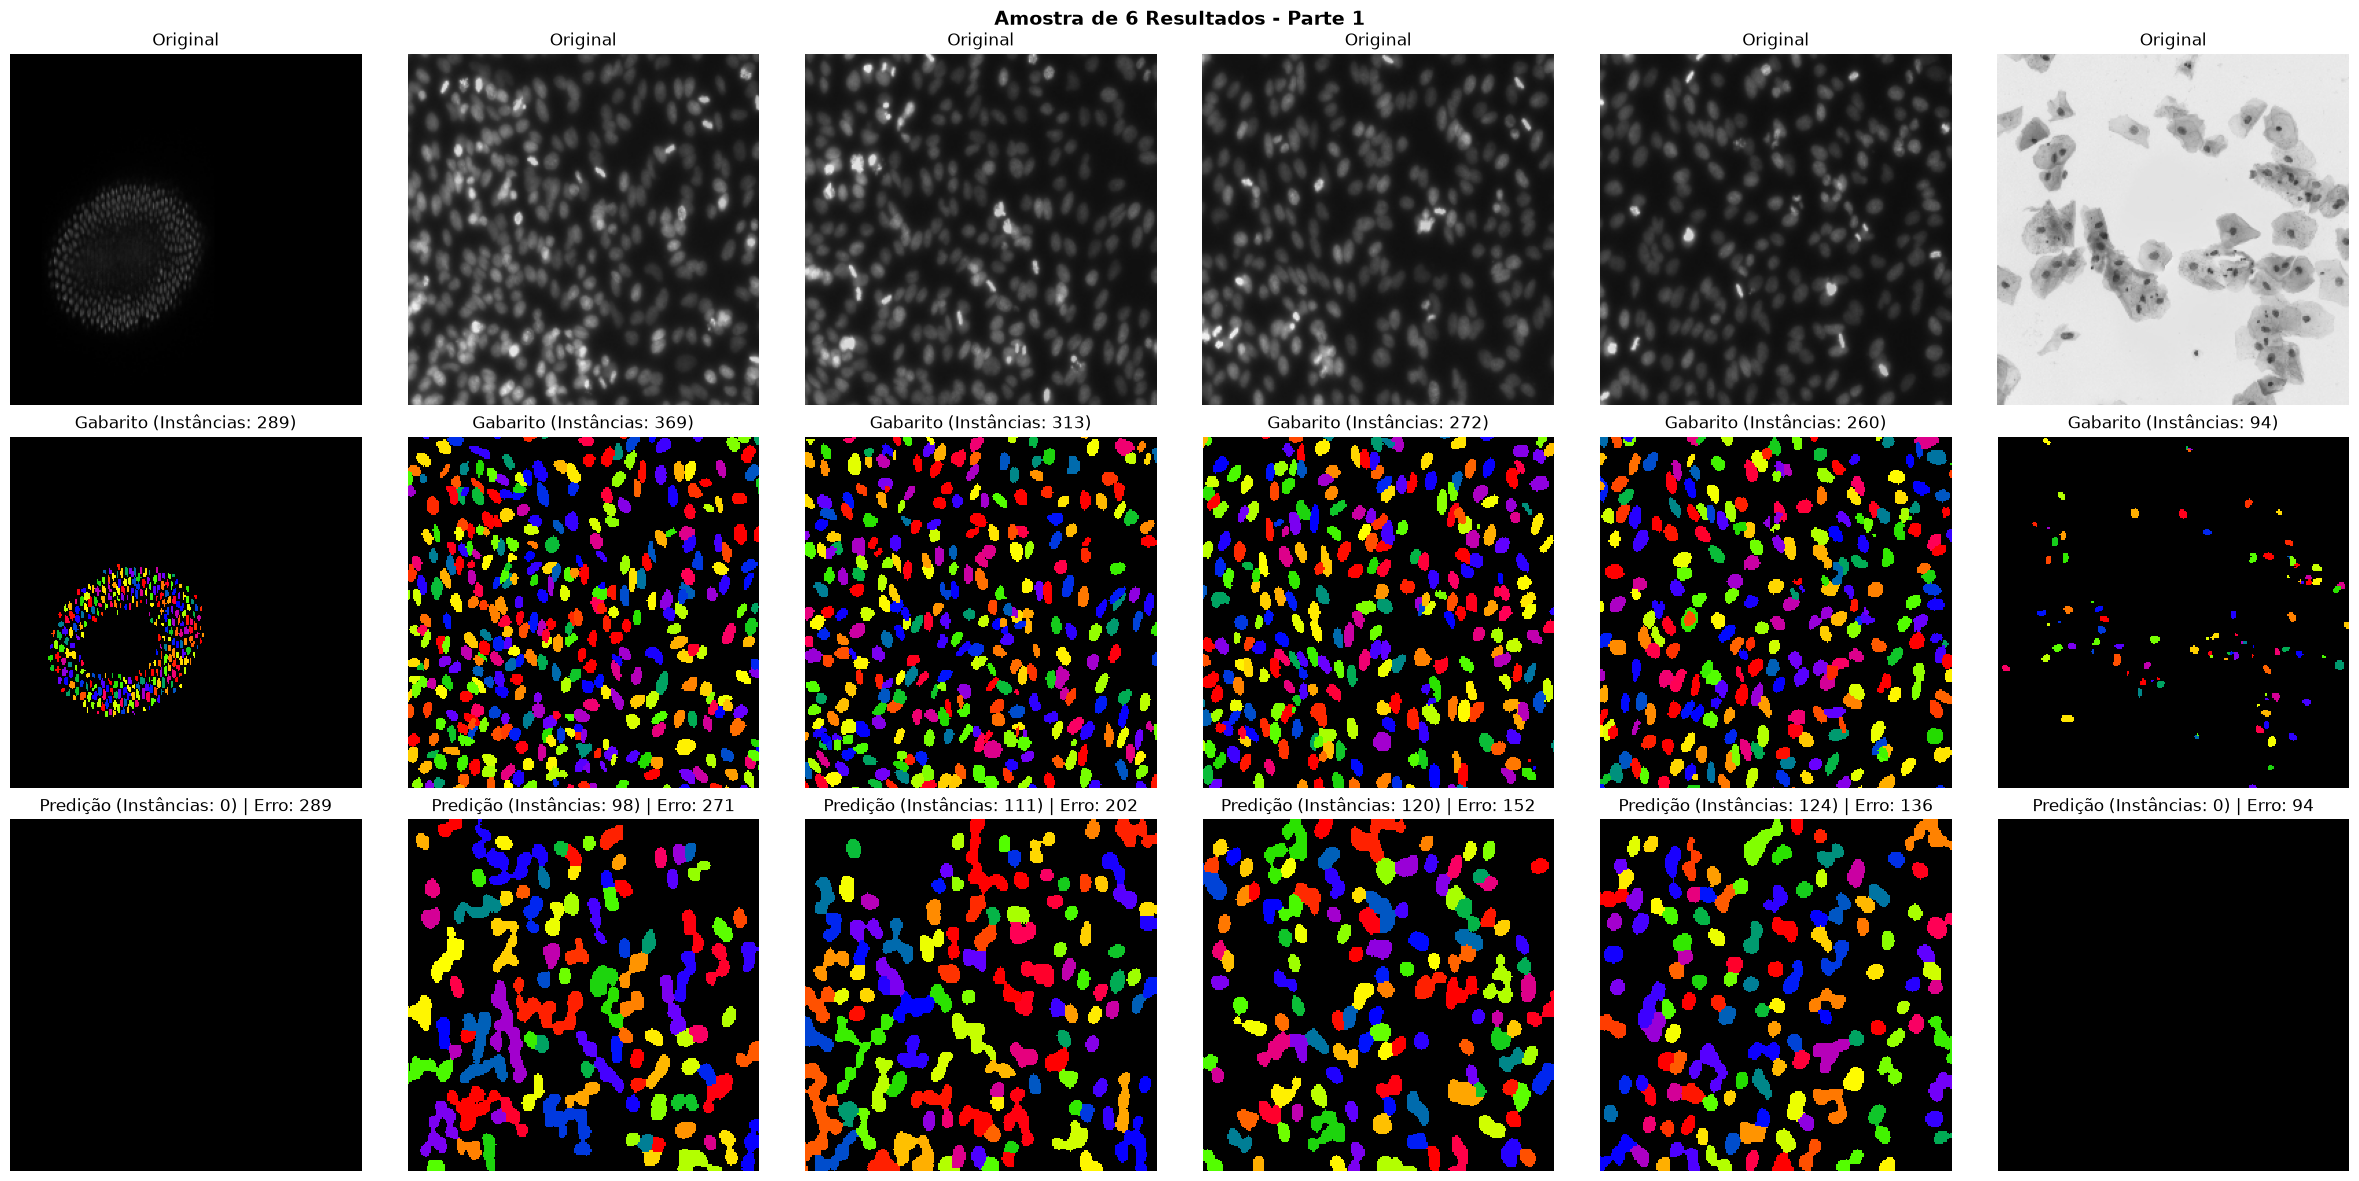

In [43]:
# Avaliação
model_ternary.load_state_dict(torch.load('../models/best_model_ternary.pt', map_location=DEVICE, weights_only=True))

aps_ternary, count_errors_ternary, densities_ternary, per_image_aps_ternary, samples_ternary = evaluate_instances_ternary(model_ternary, val_loader_ternary)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_ternary[i]:.4f} | {per_image_aps_ternary[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_ternary):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_ternary):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_ternary):.4f}")

plot_metrics(per_image_aps_ternary, count_errors_ternary, densities_ternary)
plot_samples(samples_ternary)

Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

### Parte 3

In [9]:
ablation(train_ds_ternary, val_ds_ternary)


ModuleNotFoundError: No module named 'dataset'

In [ ]:
ablation(traiin)

### Parte 4

In [4]:
mosaic_img, mosaic_inst = create_mosaic_real(val_ds_ternary, indices=[0, 1, 2, 3])

print(f"📦 Formato da imagem do mosaico: {mosaic_img.shape}")
print(f"🏷️ Formato da máscara de instâncias do mosaico: {mosaic_inst.shape}")
print(f"🔢 Total de instâncias únicas no mosaico: {len(np.unique(mosaic_inst)) - 1}")


📦 Formato da imagem do mosaico: (3, 512, 512)
🏷️ Formato da máscara de instâncias do mosaico: (512, 512)
🔢 Total de instâncias únicas no mosaico: 168


In [5]:
tiles, coords = mosaic_tile_inference_demo(mosaic_img, tile_size=128, overlap=32)

print(f"🧩 Número total de tiles gerados: {len(tiles)}")
print(f"📍 Coordenadas (y_start, y_end, x_start, x_end) do primeiro tile: {coords[0]}")
print(f"📦 Formato de cada tile: {tiles[0].shape}")

🧩 Número total de tiles gerados: 25
📍 Coordenadas (y_start, y_end, x_start, x_end) do primeiro tile: (0, 128, 0, 128)
📦 Formato de cada tile: (3, 128, 128)


Número de instâncias: 246


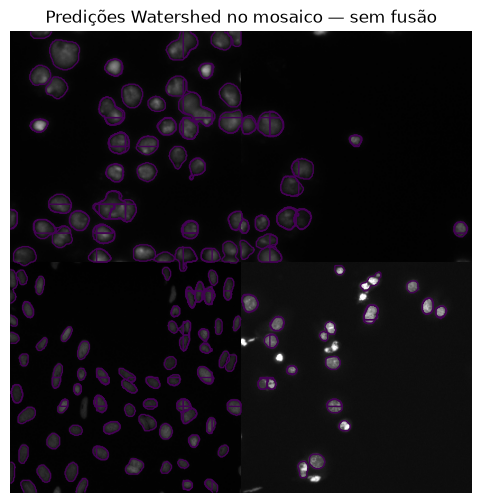

In [6]:
# real_model = UNetBinary()
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# start = time.time()
# train_model(real_model, real_train_loader, device, part=1, num_epochs=5)
# print(f"Training time: {(time.time() - start) / 60:.2f} minutes")
# real_mAP, real_count_errors, real_densities, synthetic_samples = evaluate(real_model, real_val_loader, device, part =1)
# plot_metrics(real_mAP, real_count_errors, real_densities)
# plot_samples(synthetic_samples, part=1)

model_ternary = UNetTernary().to(DEVICE)


model_ternary.load_state_dict(torch.load('../models/best_model_ternary.pt', map_location=DEVICE, weights_only=True))

pred_naive = mosaic_inference_naive_watershed(
    model=model_ternary,
    mosaic_img=mosaic_img,
    tile_size=128,
    stride=96,
    device=DEVICE,
    interior_thresh=0.4,
    fg_thresh=0.5,
    min_marker_size=5
)
print("Número de instâncias:", len(pred_naive))

plt.figure(figsize=(12, 6))

plt.imshow(mosaic_img.transpose(1, 2, 0))

for mask in pred_naive:
    plt.contour(mask, levels=[0.5], linewidths=1)

plt.axis("off")
plt.title("Predições Watershed no mosaico — sem fusão")
plt.show()

In [15]:
pred_fusion_labels = mosaic_inference_watershed_with_fusion(
    model=    model_ternary,
    large_image=mosaic_img,
    tile_size=128,
    overlap=32,
    device=DEVICE,
    interior_thresh=0.4,
    fg_thresh=0.5,
    min_marker_size=5,
    fusion_iou_thresh=0.3,
)

pred_fusion = label_mask_to_instances(
    pred_fusion_labels
)

In [16]:
print("Número de instâncias após fusão:",
      len(np.unique(pred_fusion_labels)) - 1)

Número de instâncias após fusão: 139


TypeError: Input z must be 2D, not 3D

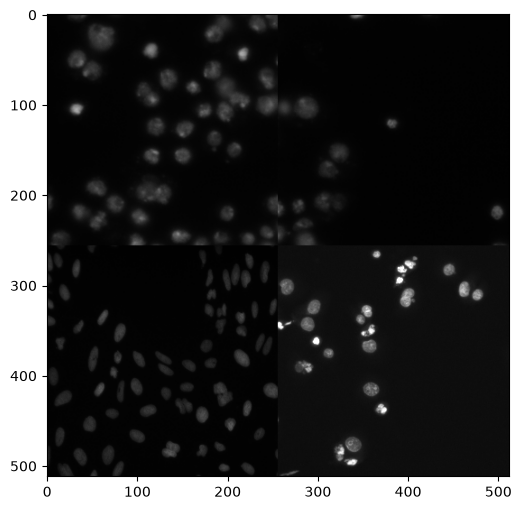

In [14]:
plt.figure(figsize=(12, 6))

plt.imshow(mosaic_img.transpose(1, 2, 0))

for instance_id in np.unique(pred_fusion):

    if instance_id == 0:
        continue

    mask = pred_fusion == instance_id

    plt.contour(
        mask,
        levels=[0.5],
        linewidths=1
    )

plt.axis("off")
plt.title("Predições Watershed no mosaico — com fusão")
plt.show()

In [10]:
for thresh in [0.2, 0.3, 0.5, 0.7]:
    
    pred = mosaic_inference_watershed_with_fusion(
        model=model_ternary,
        large_image=mosaic_img,
        tile_size=128,
        overlap=32,
        device=DEVICE,
        interior_thresh=0.4,
        fg_thresh=0.5,
        min_marker_size=5,
        fusion_iou_thresh=thresh,
    )

    n_instances = len(np.unique(pred)) - 1

    print(
        f"IoU = {thresh:.1f} → "
        f"{n_instances} instâncias"
    )

IoU = 0.2 → 138 instâncias
IoU = 0.3 → 139 instâncias
IoU = 0.5 → 140 instâncias
IoU = 0.7 → 141 instâncias


In [17]:
gt_masks = label_mask_to_instances(mosaic_inst)

print("Número de instâncias GT:", len(gt_masks))
print("Shape de cada máscara:", gt_masks[0].shape)

Número de instâncias GT: 168
Shape de cada máscara: (512, 512)


In [18]:
aps_naive, map_naive, count_naive = evaluate_mosaic_instances(
    pred_naive,
    gt_masks
)

aps_fusion, map_fusion, count_fusion = evaluate_mosaic_instances(
    pred_fusion,
    gt_masks
)

In [19]:
print("======================================")
print("NAIVE")
print("======================================")
print(f"Instâncias previstas: {len(pred_naive)}")
print(f"Instâncias GT:        {len(gt_masks)}")
print(f"Erro de contagem:     {count_naive}")
print(f"mAP:                  {map_naive:.4f}")

print()

print("======================================")
print("FUSION")
print("======================================")
print(f"Instâncias previstas: {len(pred_fusion)}")
print(f"Instâncias GT:        {len(gt_masks)}")
print(f"Erro de contagem:     {count_fusion}")
print(f"mAP:                  {map_fusion:.4f}")

NAIVE
Instâncias previstas: 246
Instâncias GT:        168
Erro de contagem:     78
mAP:                  0.2819

FUSION
Instâncias previstas: 139
Instâncias GT:        168
Erro de contagem:     29
mAP:                  0.4104


A inferência naive produziu 246 instâncias para 168 instâncias reais, resultando em erro absoluto de contagem de 78 objetos e mAP de 0,2819. Após a aplicação da fusão baseada em IoU nas regiões de sobreposição dos tiles, o número de instâncias previstas foi reduzido para 139, diminuindo o erro de contagem para 29 e elevando o mAP para 0,4104. Os resultados indicam que uma parcela significativa das detecções adicionais da abordagem naive correspondia a duplicações de instâncias entre tiles. Entretanto, a fusão também pode eliminar ou unir incorretamente algumas instâncias, como indicado pela subcontagem final de 29 objetos.

### Parte 5